# **Building an AI Clinician: Offline RL for ICU Hemodynamic Management**
### **Dataset**: MIMIC-III (Google BigQuery)

### **Prerequisites**: Ensure that you're using running this notebook on the same Google account that you've set MIMIC-III Dataset on Google BigQuery.

For more inforamtion on how to use Google BigQuey check out this tutorial  [**Click Here**](https://utexas.instructure.com/courses/1435390/files/88672934?wrap=1)

## **Overview**

### In this notebook, we build an Offline RL agent with Double Deep Q-Network (DDQN) to learn optimal dosing strategies for IV Fluids and Vasopressors for septic patients.

*   IV Fluids increase overall blood volume to stabilize the patient.

*   Vasopressors (like Norepinephrine and Dopamine) constrict those blood vessels to actively raise blood pressure.


### We group these various medications into just these two categories because by keeping the agents' action space small ($5 \times 5 = 25$ total actions), we ensure the model has enough dense historical data to learn a reliable policy.

### The RL agent learns to balance immediate physiological stabilization (measured via SOFA scores) with the ultimate goal of maximizing overall patient survival.


---



---



# **Step 1: Environment Setup and BigQuery Authentication**
### To train our Reinforcement Learning agent, we first need real-world clinical data. We will be using the MIMIC-III database, which is publicly hosted on Google BigQuery. This first block authenticates your Google Colab session so you can query the database directly from this notebook.
For more inforamtion on how to use Google BigQuey check out this tutorial  [**Click Here**](https://utexas.instructure.com/courses/1435390/files/88672934?wrap=1)

In [1]:
# Import required libraries
import pandas as pd
from google.colab import auth
from google.cloud import bigquery
from IPython.display import display

# The following code will trigger a popup asking for your Google credentials.
# You must log in with the account that has access to the MIMIC-III dataset set on Google BigQuery.
auth.authenticate_user()
print("Authentication successful!")

# Your Google Cloud billing project ID/ found in BigQuery Console dashboard
proj_id = 'groovy-legacy-487313-b6'

# Initialize the BigQuery client
client = bigquery.Client(project=proj_id)
print(f"BigQuery Client initialized for project: {proj_id}")

Authentication successful!
BigQuery Client initialized for project: groovy-legacy-487313-b6


# **Step 2: Patient Cohort Extraction**
### Before we can build a Reinforcement Learning environment, we need to define our "episodes." In this medical context, one episode is equal to one patient's stay in the Intensive Care Unit (ICU).

### So first we queries the MIMIC-III database to extract our baseline cohort by joining the icustays, admissions, and patients tables to get the ICU Stay IDs, admission times, length of stay, and the ultimate outcome (whether the patient survived or died in the hospital), filtering specifically for adult patients who stayed in the ICU for at least 12 hours.

In [3]:
from IPython.display import display

# SQL Query to pull the cohort data
query = """
SELECT
    ie.icustay_id AS ICUSTAY_ID,
    ie.intime AS INTIME,
    ie.outtime AS OUTTIME,
    ie.los AS LOS,
    adm.hospital_expire_flag AS HOSPITAL_EXPIRE_FLAG
FROM
    `physionet-data.mimiciii_clinical.icustays` ie
INNER JOIN
    `physionet-data.mimiciii_clinical.admissions` adm
    ON ie.hadm_id = adm.hadm_id
INNER JOIN
    `physionet-data.mimiciii_clinical.patients` pat
    ON ie.subject_id = pat.subject_id
WHERE
    DATETIME_DIFF(ie.intime, pat.dob, YEAR) >= 18
    AND ie.los >= 0.5
"""

# Convert the query results into a DataFrame
df1 = client.query(query).to_dataframe()

# Drop any rows with missing data to ensure a clean baseline
df1 = df1.dropna(subset=['ICUSTAY_ID', 'INTIME', 'HOSPITAL_EXPIRE_FLAG'])

# Calculate mortality stats for the cohort
Number_of_Patients = len(df1)
mort_rate = df1['HOSPITAL_EXPIRE_FLAG'].mean() * 100

print(f"Total ICU Stays (Episodes): {Number_of_Patients}")
print(f"Baseline Cohort Mortality Rate: {mort_rate:.2f}%\n")

print("Sample Data:")
display(df1.head())

Total ICU Stays (Episodes): 52317
Baseline Cohort Mortality Rate: 11.60%

Sample Data:


,ICUSTAY_ID,INTIME,OUTTIME,LOS,HOSPITAL_EXPIRE_FLAG
0,203333,2133-10-23 15:19:16,2133-10-29 21:27:49,6.2559,0
1,299036,2122-08-07 14:35:31,2122-08-09 22:45:29,2.3403,0
2,209490,2143-08-21 00:20:52,2143-08-24 14:28:40,3.5888,0
3,212996,2154-07-02 12:09:06,2154-07-08 14:23:46,6.0935,0
4,294198,2186-08-12 12:11:41,2186-08-30 18:53:52,18.2793,0


# **Step 3: Extracting the "State" Variables (Vital Signs)**

### In Reinforcement Learning, the agent needs to know the State ($S_t$) of the environment to make a decision. For our ICU agent, the "environment" is the patient, and the state is represented by their vital signs.
### So, we use query to filter only our 4 essential vital signs (Heart Rate, Mean Arterial Pressure, SpO2, and Temperature) and pre-aggregate them by the hour and finally we group these hourly logs into the 4-hour time blocks that will serve as the distinct "steps" in our Reinforcement Learning trajectory.

In [5]:
# SQL query to extract vital signs by the hour
# ITEMIDs map to specific measurements (for example 211 and 220045 both represent Heart Rate)
query2 = """
SELECT
    icustay_id AS ICUSTAY_ID,
    DATETIME_TRUNC(charttime, HOUR) AS CHARTTIME,
    AVG(CASE WHEN itemid IN (211, 220045) THEN valuenum END) AS HR,
    AVG(CASE WHEN itemid IN (52, 456, 6702, 443, 220052, 220181, 225312) THEN valuenum END) AS MAP,
    AVG(CASE WHEN itemid IN (646, 220277) THEN valuenum END) AS SpO2,
    AVG(CASE WHEN itemid IN (676, 677, 678, 679, 223761, 223762) THEN valuenum END) AS Temp
FROM `physionet-data.mimiciii_clinical.chartevents`
WHERE itemid IN (211, 220045, 52, 456, 6702, 443, 220052, 220181, 225312,
                 646, 220277, 676, 677, 678, 679, 223761, 223762)
  AND valuenum IS NOT NULL
  AND error IS DISTINCT FROM 1
GROUP BY ICUSTAY_ID, CHARTTIME
"""

df_vitals = client.query(query2).to_dataframe()
display(df_vitals.head())

,ICUSTAY_ID,CHARTTIME,HR,MAP,SpO2,Temp
0,222626,2132-12-21 12:00:00,118.000000,83.000000,96.000000,67.799999
1,284442,2195-07-26 10:00:00,44.000000,88.000000,98.000000,NaN
2,266343,2184-07-13 12:00:00,69.285714,57.571429,99.142857,99.800000
3,239471,2170-06-29 21:00:00,96.750000,55.000000,98.000000,NaN
4,224756,2181-06-02 02:00:00,56.000000,90.000000,96.000000,NaN


In [6]:
# Convert CHARTTIME to datetime objects
df_vitals['CHARTTIME'] = pd.to_datetime(df_vitals['CHARTTIME'])

# Discretize time into 4-hour blocks (decision-making frequency of RL Model)
df_vitals['Time_Block'] = df_vitals['CHARTTIME'].dt.floor('4h')

# Aggregate the hourly data into the 4-hour blocks by taking the mean
df_state = df_vitals.groupby(['ICUSTAY_ID', 'Time_Block'])[['HR', 'MAP', 'SpO2', 'Temp']].mean().reset_index()

# We Forward-fill missing values, by assuming that vital signs are stable (almost the same) until new record
df_state = df_state.sort_values(['ICUSTAY_ID', 'Time_Block'])
df_state[['HR', 'MAP', 'SpO2', 'Temp']] = df_state.groupby('ICUSTAY_ID')[['HR', 'MAP', 'SpO2', 'Temp']].ffill()

# Fill any remaining NaNs with the population median
df_state[['HR', 'MAP', 'SpO2', 'Temp']] = df_state[['HR', 'MAP', 'SpO2', 'Temp']].fillna(df_state[['HR', 'MAP', 'SpO2', 'Temp']].median())

print(f"Total Trajectory Steps: {len(df_state)}\n")

print("Sample of the Patient State Matrix (S_t):")
display(df_state.head(8))

Total Trajectory Steps: 1773657

Sample of the Patient State Matrix (S_t):


,ICUSTAY_ID,Time_Block,HR,MAP,SpO2,Temp
0,200001,2181-11-25 16:00:00,114.50,77.000,94.500000,99.1
1,200001,2181-11-25 20:00:00,108.25,76.250,97.250000,99.8
2,200001,2181-11-26 00:00:00,98.25,65.500,98.500000,99.8
3,200001,2181-11-26 04:00:00,89.75,67.500,100.000000,98.1
4,200001,2181-11-26 08:00:00,107.75,66.750,99.750000,97.5
5,200001,2181-11-26 12:00:00,103.00,63.625,98.500000,99.4
6,200001,2181-11-26 16:00:00,94.25,68.750,96.250000,99.6
7,200001,2181-11-26 20:00:00,89.50,68.750,98.333333,97.3


# **Step 4: Extracting the "Action" Variables (Treatments)**

### Now we need to extract the Actions ($A_t$) taken by the human doctors.

### In this tutorial, the RL agent will control two specific critical care interventions: IV Fluids and Vasopressors (medications used to raise blood pressure).

### We will query the inputevents_mv table in MIMIC-III to get the dosages administered. Just like the vital signs, we must group these dosages into the exact same 4-hour time blocks so they align perfectly with our state variables.

In [7]:
# SQL query to extract a comprehensive list of fluids and vasopressors
# IV FLUIDS (Isotonic Crystalloids): 225158 = NaCl 0.9% / 225159 = Lactated Ringers
# VASOPRESSORS:# 220119 = Norepinephrine
# 220120 = Epinephrine
# 221662 = Dopamine
# 221749 = Phenylephrine
# 222315 = Vasopressin

query3 = """
SELECT
    icustay_id AS ICUSTAY_ID,
    starttime AS STARTTIME,
    itemid AS ITEMID,
    amount AS AMOUNT
FROM `physionet-data.mimiciii_clinical.inputevents_mv`
WHERE itemid IN (
    225158, 225159,
    220119, 220120, 221662, 221749, 222315
)
  AND amount IS NOT NULL
  AND statusdescription != 'Rewritten'
"""

actions = client.query(query3).to_dataframe()
display(actions.head())

,ICUSTAY_ID,STARTTIME,ITEMID,AMOUNT
0,263487,2104-01-18 15:56:00,221749,3.039826
1,224930,2130-07-24 16:22:00,221749,1.733126
2,275650,2184-09-15 21:50:00,221749,0.400000
3,258054,2174-03-25 17:51:00,221749,1.252879
4,259715,2187-12-11 02:00:00,221749,4.571411


In [8]:
# Check the counts of all vasopressors, just to make sure querry is correct, otherwise missing Vasopressors leads to bais in the actions history that agent will learn from
# This map was generated By Gemnini LLM to save time
itemid_names = {
    225158: 'NaCl 0.9% (IV Fluid)', 225159: 'Lactated Ringers (IV Fluid)',
    220119: 'Norepinephrine (Vasopressor)', 220120: 'Epinephrine (Vasopressor)',
    221662: 'Dopamine (Vasopressor)', 221749: 'Phenylephrine (Vasopressor)',
    222315: 'Vasopressin (Vasopressor)'
}
# print the breakdown
print("\nBreakdown of Raw Administrations by Drug")
drugcounts = actions['ITEMID'].map(itemid_names).value_counts()
print(drugcounts)
print("------------------------------------------------\n")


Breakdown of Raw Administrations by Drug
ITEMID
NaCl 0.9% (IV Fluid)           402792
Phenylephrine (Vasopressor)     72906
Dopamine (Vasopressor)           8470
Lactated Ringers (IV Fluid)      5714
Vasopressin (Vasopressor)        4145
Name: count, dtype: int64
------------------------------------------------



In [9]:
#Convert STARTTIME to datetime and floor to our 4-hour RL steps
actions['STARTTIME'] = pd.to_datetime(actions['STARTTIME'])
actions['Time_Block'] = actions['STARTTIME'].dt.floor('4H')

# Now we Map the different medications/treatments by thier ITEMIDs to our two intervention categories for RL, IV_Fluid and Vasopressor
action_map = {
    225158: 'IV_Fluid', 225159: 'IV_Fluid',
    220119: 'Vasopressor', 220120: 'Vasopressor',
    221662: 'Vasopressor', 221749: 'Vasopressor', 222315: 'Vasopressor'
}
actions['Action_Name'] = actions['ITEMID'].map(action_map)
display(actions.head())

/tmp/ipykernel_21531/1449141627.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  actions['Time_Block'] = actions['STARTTIME'].dt.floor('4H')


,ICUSTAY_ID,STARTTIME,ITEMID,AMOUNT,Time_Block,Action_Name
0,263487,2104-01-18 15:56:00,221749,3.039826,2104-01-18 12:00:00,Vasopressor
1,224930,2130-07-24 16:22:00,221749,1.733126,2130-07-24 16:00:00,Vasopressor
2,275650,2184-09-15 21:50:00,221749,0.400000,2184-09-15 20:00:00,Vasopressor
3,258054,2174-03-25 17:51:00,221749,1.252879,2174-03-25 16:00:00,Vasopressor
4,259715,2187-12-11 02:00:00,221749,4.571411,2187-12-11 00:00:00,Vasopressor


In [10]:
# Group by patient, time block, and action type, summing the total dosage
actions_grouped = (actions.groupby(['ICUSTAY_ID', 'Time_Block', 'Action_Name'])['AMOUNT']
                      .sum()
                      .unstack(fill_value=0) # Pivot action names into columns
                      .reset_index())

# Robustness check: Ensure both columns exist
for action in ['IV_Fluid', 'Vasopressor']:
    if action not in actions_grouped.columns:
        actions_grouped[action] = 0.0

print(f"Total Action Records: {len(actions_grouped)}\n")

print("Sample of the Action Matrix (A_t):")
display(actions_grouped.head(8))

# Let's check how many non-zero vasopressors we actually captured now!
vaso_count = (actions_grouped['Vasopressor'] > 0).sum()
print(f"\nTotal 4-hour blocks where a Vasopressor was given: {vaso_count}")

Total Action Records: 186748

Sample of the Action Matrix (A_t):


Action_Name,ICUSTAY_ID,Time_Block,IV_Fluid,Vasopressor
0,200001,2181-11-25 20:00:00,200.000006,0.0
1,200001,2181-11-27 20:00:00,250.000000,0.0
2,200010,2132-08-05 00:00:00,1017.708333,0.0
3,200010,2132-08-05 04:00:00,1000.000000,0.0
4,200010,2132-08-05 08:00:00,1000.000000,0.0
5,200016,2150-12-02 16:00:00,999.999974,0.0
6,200016,2150-12-03 04:00:00,696.250000,0.0
7,200021,2114-12-26 20:00:00,2000.000000,0.0



Total 4-hour blocks where a Vasopressor was given: 35479


# **Step 5: Extracting the Reward Signal (SOFA Score)**
### To train our RL agent, we must give it feedback on whether its actions are helping or hurting the patient. We use the Sequential Organ Failure Assessment (SOFA) score.

### A dropping SOFA score means the patient's organs are recovering (positive reward), while a rising score indicates deterioration (negative reward).

### So now we pull the hourly SOFA scores from the MIMIC-III derived tables then we merge it with our cohort data to calculate the real timestamp and finally group these scores into our standard 4-hour time blocks by taking the worst (maximum) SOFA score recorded in that window.



In [11]:
query4 = """
SELECT
    icustay_id AS ICUSTAY_ID,
    hr,
    sofa_24hours AS sofa_score
FROM `physionet-data.mimiciii_derived.pivoted_sofa`
WHERE icustay_id IS NOT NULL
  AND sofa_24hours IS NOT NULL
"""

df_sofa = client.query(query4).to_dataframe()
display(df_sofa.head())

,ICUSTAY_ID,hr,sofa_score
0,250484,278,19
1,204016,981,18
2,271785,121,17
3,249337,222,18
4,246477,133,17


In [12]:
# Merge the querry results with df1 to get the patient's admission time (INTIME)
df_sofa2 = df_sofa.merge(df1[['ICUSTAY_ID', 'INTIME']], on='ICUSTAY_ID')

# Convert the integer 'hr' (which is the time in hours since admission) into real-world timestamp
df_sofa2['CHARTTIME'] = df_sofa2['INTIME'] + pd.to_timedelta(df_sofa2['hr'], unit='h')

# Discretize time into our standard 4-hour blocks, the RL agent steps
df_sofa2['Time_Block'] = df_sofa2['CHARTTIME'].dt.floor('4h')

# Take the maximum (Higher means worst patient condition) SOFA score recorded within that 4-hour block
sofa_grouped = (df_sofa2.groupby(['ICUSTAY_ID', 'Time_Block'])['sofa_score']
                   .max()
                   .reset_index())

print(f"Total SOFA Records: {len(sofa_grouped)}\n")

print("Sample of the SOFA Score Data:")
display(sofa_grouped.head())

Total SOFA Records: 1378930

Sample of the SOFA Score Data:


,ICUSTAY_ID,Time_Block,sofa_score
0,200001,2181-11-25 16:00:00,3
1,200001,2181-11-25 20:00:00,4
2,200001,2181-11-26 00:00:00,5
3,200001,2181-11-26 04:00:00,5
4,200001,2181-11-26 08:00:00,5


# **Step 6: Constructing the Master Trajectory Timeline**
### To train we need to see the sequence of events exactly as they happened: State → Action → Reward → Next State.

### In this block, we merge the three separate dataframes (Vital Signs, Treatments, and SOFA scores) into a single master timeline using the patient's ICUSTAY_ID and the 4-hour Time_Block. If a patient did not receive any drugs during a 4-hour window, we safely fill those action values with 0.

In [19]:
# Start with the State timeline as our base
df_master = df_state.copy()

# Merge Actions
df_master = df_master.merge(actions_grouped, on=['ICUSTAY_ID', 'Time_Block'], how='left')

# Merge Rewards (SOFA scores)
df_master = df_master.merge(sofa_grouped, on=['ICUSTAY_ID', 'Time_Block'], how='left')

# If an action is NaN, it means the doctor gave 0 dosage during that 4-hour block
df_master['IV_Fluid'] = df_master['IV_Fluid'].fillna(0)
df_master['Vasopressor'] = df_master['Vasopressor'].fillna(0)

# Sort by patient and time to ensure sequential order
df_master = df_master.sort_values(['ICUSTAY_ID', 'Time_Block']).reset_index(drop=True)

# For SOFA scores, we forward-fill missing values,
df_master['sofa_score'] = df_master.groupby('ICUSTAY_ID')['sofa_score'].ffill().bfill()

# Finally, drop any remaining NaNs (e.g., if a patient had no SOFA scores at all)
df_master = df_master.dropna()

print(f"Total Trajectory Steps: {len(df_master)}")
print(f"Total Unique Patients: {df_master['ICUSTAY_ID'].nunique()}\n")

print("Sample of the Master Trajectory (S_t, A_t):")
display(df_master.head(8))

Total Trajectory Steps: 1773657
Total Unique Patients: 60188

Sample of the Master Trajectory (S_t, A_t):


,ICUSTAY_ID,Time_Block,HR,MAP,SpO2,Temp,IV_Fluid,Vasopressor,sofa_score
0,200001,2181-11-25 16:00:00,114.50,77.000,94.500000,99.1,0.000000,0.0,3
1,200001,2181-11-25 20:00:00,108.25,76.250,97.250000,99.8,200.000006,0.0,4
2,200001,2181-11-26 00:00:00,98.25,65.500,98.500000,99.8,0.000000,0.0,5
3,200001,2181-11-26 04:00:00,89.75,67.500,100.000000,98.1,0.000000,0.0,5
4,200001,2181-11-26 08:00:00,107.75,66.750,99.750000,97.5,0.000000,0.0,5
5,200001,2181-11-26 12:00:00,103.00,63.625,98.500000,99.4,0.000000,0.0,6
6,200001,2181-11-26 16:00:00,94.25,68.750,96.250000,99.6,0.000000,0.0,6
7,200001,2181-11-26 20:00:00,89.50,68.750,98.333333,97.3,0.000000,0.0,6


# **Step 7: Discretizing Actions & Calculating the Constrained Reward**
### Since Our RL agent will use Deep Q-Networks (DQN), we cann't train on the continouse values/dosages of treatment, instead we require a discrete action space. Since Real-world medical dosages are continuous, we must categorize them into "Bins":

*   We reserve Bin 0 strictly for "No Drug Given."
For any non-zero dosages,
*   Bins 1 through 4 (The Quartiles): We take all the times doctors did give a drug (the non-zero doses), and divide them into 4 equal-sized buckets based on frequency.

### Since we have 5 bins for IV Fluids and 5 bins for Vasopressors, this creates a total action space of $5 \times 5 = 25$ possible treatment combinations.

### Additionally, we calculate the Constrained Reward. If we only reward the AI for improving the SOFA score, it will "hack" the system by maximizing drug dosages. By subtracting a "dosage penalty," we force the agent to find the minimum effective dose.

In [16]:
def discretize_action(df, col_name, num_bins=5):
    zero_mask = df[col_name] == 0
    non_zero_doses = df.loc[~zero_mask, col_name]

    if len(non_zero_doses) > 0:
        # pd.qcut creates equal-frequency buckets for the non-zero doses
        binned = pd.qcut(non_zero_doses, q=num_bins-1, labels=False, duplicates='drop')
        # Shift labels by 1 so '0' is reserved for 'no dose'
        df.loc[~zero_mask, f'{col_name}_Bin'] = binned + 1
    else:
        df[f'{col_name}_Bin'] = 0

    df[f'{col_name}_Bin'] = df[f'{col_name}_Bin'].fillna(0).astype(int)
    return df

In [20]:
print("Before Discretize")
print("\n========================================")
display(df_master.head())
print("\n========================================")

# Discretize IV Fluids and Vasopressors
df_master = discretize_action(df_master, 'IV_Fluid')
df_master = discretize_action(df_master, 'Vasopressor')

print("After Discretize")
print("\n========================================")
display(df_master.head())

Before Discretize



,ICUSTAY_ID,Time_Block,HR,MAP,SpO2,Temp,IV_Fluid,Vasopressor,sofa_score
0,200001,2181-11-25 16:00:00,114.50,77.00,94.50,99.1,0.000000,0.0,3
1,200001,2181-11-25 20:00:00,108.25,76.25,97.25,99.8,200.000006,0.0,4
2,200001,2181-11-26 00:00:00,98.25,65.50,98.50,99.8,0.000000,0.0,5
3,200001,2181-11-26 04:00:00,89.75,67.50,100.00,98.1,0.000000,0.0,5
4,200001,2181-11-26 08:00:00,107.75,66.75,99.75,97.5,0.000000,0.0,5



After Discretize



,ICUSTAY_ID,Time_Block,HR,MAP,SpO2,Temp,IV_Fluid,Vasopressor,sofa_score,IV_Fluid_Bin,Vasopressor_Bin
0,200001,2181-11-25 16:00:00,114.50,77.00,94.50,99.1,0.000000,0.0,3,0,0
1,200001,2181-11-25 20:00:00,108.25,76.25,97.25,99.8,200.000006,0.0,4,3,0
2,200001,2181-11-26 00:00:00,98.25,65.50,98.50,99.8,0.000000,0.0,5,0,0
3,200001,2181-11-26 04:00:00,89.75,67.50,100.00,98.1,0.000000,0.0,5,0,0
4,200001,2181-11-26 08:00:00,107.75,66.75,99.75,97.5,0.000000,0.0,5,0,0


In [23]:
# Combine into a single 1D action space (0 to 24)
df_master['Action'] = (df_master['IV_Fluid_Bin'] * 5) + df_master['Vasopressor_Bin']
display(df_master.head())

print("--- IV Fluid Bin Counts ---")
print(df_master['IV_Fluid_Bin'].value_counts().sort_index())
print("\n--- Vasopressor Bin Counts ---")
print(df_master['Vasopressor_Bin'].value_counts().sort_index())

,ICUSTAY_ID,Time_Block,HR,MAP,SpO2,Temp,IV_Fluid,Vasopressor,sofa_score,IV_Fluid_Bin,Vasopressor_Bin,Action
0,200001,2181-11-25 16:00:00,114.50,77.00,94.50,99.1,0.000000,0.0,3,0,0,0
1,200001,2181-11-25 20:00:00,108.25,76.25,97.25,99.8,200.000006,0.0,4,3,0,15
2,200001,2181-11-26 00:00:00,98.25,65.50,98.50,99.8,0.000000,0.0,5,0,0,0
3,200001,2181-11-26 04:00:00,89.75,67.50,100.00,98.1,0.000000,0.0,5,0,0,0
4,200001,2181-11-26 08:00:00,107.75,66.75,99.75,97.5,0.000000,0.0,5,0,0,0


--- IV Fluid Bin Counts ---
IV_Fluid_Bin
0    1588667
1      46421
2      46119
3      46607
4      45843
Name: count, dtype: int64

--- Vasopressor Bin Counts ---
Vasopressor_Bin
0    1738193
1       8866
2       8866
3       8866
4       8866
Name: count, dtype: int64


In [24]:
print("\n--- 2D Action Grid (Clinician Historical Actions) ---")
# This creates a table showing exactly how many times each combination was used
action_grid = pd.crosstab(df_master['IV_Fluid_Bin'], df_master['Vasopressor_Bin'])
display(action_grid)
print("=====================================================================\n")


--- 2D Action Grid (Clinician Historical Actions) ---


Vasopressor_Bin,0,1,2,3,4
IV_Fluid_Bin,,,,,
0,1587031,92,131,293,1120
1,36246,6023,3252,507,393
2,37476,817,3014,3875,937
3,38286,791,1206,2558,3766
4,39154,1143,1263,1633,2650


In [28]:
#Calculate the Constrained Reward
# lambda_penalty --> Hyperparameter for The 'cost' of giving drugs.
lambda_pen = 0.01

# Reward == Drop in SOFA score is good (Positive value)
sofa_r = df_master.groupby('ICUSTAY_ID')['sofa_score'].shift(1) - df_master['sofa_score']

# Penalize the magnitude of the action bins
dosage_penalty = (df_master['IV_Fluid_Bin'] + df_master['Vasopressor_Bin']) * lambda_pen

# Final Reward Equation
df_master['Reward'] = sofa_r - dosage_penalty
df_master['Reward'] = df_master['Reward'].fillna(0)

print(f"Unique Actions identified: {df_master['Action'].nunique()} (Expected max: 25)\n")

print("Sample of the State, Action, and Reward mapping:")
display(df_master.head(10))

Unique Actions identified: 25 (Expected max: 25)

Sample of the State, Action, and Reward mapping:


,ICUSTAY_ID,Time_Block,HR,MAP,SpO2,Temp,IV_Fluid,Vasopressor,sofa_score,IV_Fluid_Bin,Vasopressor_Bin,Action,Reward
0,200001,2181-11-25 16:00:00,0.005018,-0.034377,-0.003088,1.590054,0.000000,0.0,3,0,0,0,0.0
1,200001,2181-11-25 20:00:00,0.001689,-0.047125,-0.001067,1.638262,200.000006,0.0,4,3,0,15,-1.03
2,200001,2181-11-26 00:00:00,-0.003637,-0.229850,-0.000149,1.638262,0.000000,0.0,5,0,0,0,-1.0
3,200001,2181-11-26 04:00:00,-0.008164,-0.195854,0.000953,1.521187,0.000000,0.0,5,0,0,0,0.0
4,200001,2181-11-26 08:00:00,0.001423,-0.208603,0.000770,1.479866,0.000000,0.0,5,0,0,0,0.0
5,200001,2181-11-26 12:00:00,-0.001107,-0.261720,-0.000149,1.610715,0.000000,0.0,6,0,0,0,-1.0
6,200001,2181-11-26 16:00:00,-0.005767,-0.174607,-0.001802,1.624488,0.000000,0.0,6,0,0,0,0.0
7,200001,2181-11-26 20:00:00,-0.008297,-0.174607,-0.000271,1.466093,0.000000,0.0,6,0,0,0,0.0
8,200001,2181-11-27 00:00:00,-0.010028,-0.183106,0.000770,1.514300,0.000000,0.0,7,0,0,0,-1.0
9,200001,2181-11-27 04:00:00,-0.008208,-0.017379,0.000953,1.562507,0.000000,0.0,7,0,0,0,0.0


In [29]:
#State Normalization
#Since Vital signs have differenct measurments, we need to normalize the state space, to avoid exploding gradient in training (This step was added after seeing the exploding loss)
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# List of state columns
col = ['HR', 'MAP', 'SpO2', 'Temp']

# Fit the scaler on the data and transform it
df_master[col] = scaler.fit_transform(df_master[col])

display(df_master.head())

,ICUSTAY_ID,Time_Block,HR,MAP,SpO2,Temp,IV_Fluid,Vasopressor,sofa_score,IV_Fluid_Bin,Vasopressor_Bin,Action,Reward
0,200001,2181-11-25 16:00:00,0.005018,-0.034377,-0.003088,1.590054,0.000000,0.0,3,0,0,0,0.0
1,200001,2181-11-25 20:00:00,0.001689,-0.047125,-0.001067,1.638262,200.000006,0.0,4,3,0,15,-1.03
2,200001,2181-11-26 00:00:00,-0.003637,-0.229850,-0.000149,1.638262,0.000000,0.0,5,0,0,0,-1.0
3,200001,2181-11-26 04:00:00,-0.008164,-0.195854,0.000953,1.521187,0.000000,0.0,5,0,0,0,0.0
4,200001,2181-11-26 08:00:00,0.001423,-0.208603,0.000770,1.479866,0.000000,0.0,5,0,0,0,0.0


# **Step 8: Building the PyTorch RL Environment (Dataset & DataLoader)**

### This code defines a PyTorch Dataset that iterates through our master timeline patient-by-patient, creating a tuples.

### An RL agent learns by looking at a starting state, the action taken, the reward received, and the resulting next state. This is known as the Markov Decision Process (MDP) tuple: $(S_t, A_t, R_t, S_{t+1})$

### The code also generates a Done flag (1 or 0) to tell the neural network when a patient's ICU stay has ended, which is a critical piece of the Bellman equation we will use for training.

In [30]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class ICUDataset(Dataset):
    def __init__(self, df):
        # The 4 vital signs that make up our environment State
        self.cols = ['HR', 'MAP', 'SpO2', 'Temp']

        self.states = []
        self.actions = []
        self.rewards = []
        self.next_states = []
        self.dones = []

        # Group by patient to ensure we NEVER cross-contaminate next_states between different patients
        grouped = df.groupby('ICUSTAY_ID')

        for patient_id, group in grouped:
            s = group[self.cols].values
            a = group['Action'].values
            r = group['Reward'].values

            # Iterate through the patient's timeline to create transitions
            for i in range(len(group) - 1):
                self.states.append(s[i])
                self.actions.append(a[i])
                self.rewards.append(r[i])
                self.next_states.append(s[i+1])
                self.dones.append(0) # 0 = Patient still in ICU

            # The final step of the patient's stay is terminal
            self.states.append(s[-1])
            self.actions.append(a[-1])
            self.rewards.append(r[-1])
            self.next_states.append(s[-1])
            self.dones.append(1) # 1 = Trajectory ended (Discharged/Died)

        # Convert lists to PyTorch Tensors for neural network ingestion
        self.states = torch.FloatTensor(np.array(self.states))
        self.actions = torch.LongTensor(np.array(self.actions))
        self.rewards = torch.FloatTensor(np.array(self.rewards))
        self.next_states = torch.FloatTensor(np.array(self.next_states))
        self.dones = torch.FloatTensor(np.array(self.dones))

    def __len__(self):
        return len(self.states)

    def __getitem__(self, idx):
        return self.states[idx], self.actions[idx], self.rewards[idx], self.next_states[idx], self.dones[idx]

# Instantiate the Dataset
rl_dataset = ICUDataset(df_master)
# Instantiate the DataLoader
# batch_size=128 is standard for stabilizing DQN gradients; shuffle=True
rl_dataloader = DataLoader(rl_dataset, batch_size=128, shuffle=True)

print(f"Total RL Transitions generated: {len(rl_dataset)}\n")

Total RL Transitions generated: 1773657



# **Step 9: Defining the Neural Network Architecture (Double DQN)**
### Because our state space is low-dimensional (only 4 vital signs), a standard Multi-Layer Perceptron (MLP) with two hidden layers is highly efficient and perfectly suited for this task.

### Importantly, we are implementing a Double (TWO) Deep Q-Network (DDQN) architectur because standard DQNs tend to overestimate the value of actions, which leads to the "extremist" behavior (like maxing out vasopressors dosage) which we want to avoid.

### By creating two networks, a Policy Net that learns, and a frozen Target Net that evaluates, we stabilize the learning process and create a much safer, more reliable clinical policy.

### **The target network will only  calculate the Bellman target/value:**
The Bellman Equation is the core mathematical engine of all Reinforcement Learning. It calculates the true long-term value of taking a specific action in a specific state.Mathematically: $$Q(s,a)=R+\gamma\max_{a'}Q(s',a')$$

$R$: The immediate reward of the action (e.g., the immediate drop in the SOFA score minus the drug penalty).

$\gamma\max_{a'}Q(s',a')$ (Discounted Future Reward): The highest possible value of the next state the patient enters, multiplied by a discount factor ($\gamma$) to prioritize sooner rewards over later ones.

### The Bellman equation propagates that final survival reward backward through time. It allows the neural network to mathematically connect an early action (like giving fluids on Day 1) to the ultimate outcome (survival on Day 5). It teaches the AI that taking a small immediate penalty for using drugs now is worth it if it leads to a better state later.

In [34]:
# Determine the hardware device, if running on Colab T4 GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware allocated: {device}")

Hardware allocated: cpu


In [35]:
import torch.nn as nn
import torch.nn.functional as F

class ICU_DQN(nn.Module):
    def __init__(self, input_dim=4, output_dim=25):
        super(ICU_DQN, self).__init__()
        # Input layer: 4 states (HR, MAP, Temp, SpO2)
        self.fc1 = nn.Linear(input_dim, 64)

        # Hidden layer
        self.fc2 = nn.Linear(64, 64)

        # Output layer: 25 discrete actions (5x5 grid of IV Fluid and Vasopressor)
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, x):
        # ReLU activation introduces non-linearity which allow the network to learn complex patterns
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # No activation function on the final layer because Q-values can be both positive and negative
        return self.fc3(x)

# Instantiate the Policy Network that chooses actions and updates weights
Net = ICU_DQN().to(device)

# Instantiate the Target Network that stabilizing training used only to calculate the Bellman target
target = ICU_DQN().to(device)
target.load_state_dict(Net.state_dict()) # Sync starting weights
target.eval() # Turn off gradient tracking for the target net

print("Network Structure:")
print(Net)

Network Structure:
ICU_DQN(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=25, bias=True)
)


# **Step 10: The Double DQN Training Loop**
### We use the Bellman Equation to train the network. The core trick of the Double DQN happens here:

1.   We use the active Policy Net to figure out which action is the best in the next state.
2.   We use the frozen Target Net to evaluate Q value that action will get.


In [36]:
import torch.optim as optim

learning_rate = 1e-4
gamma = 0.9       # Discount factor
epochs = 10       # Number of times to pass through the entire dataset
update_freq = 500 # How often (in batches) to sync the Target Net with the Policy Net

# Optimizer and Loss Function
optimizer = optim.Adam(Net.parameters(), lr=learning_rate)
# HuberLoss is standard for DQN.
loss_fn = nn.HuberLoss()

# Training Loop
for epoch in range(epochs):
    epoch_loss = 0.0

    for batch_idx, (states, actions, rewards, next_states, dones) in enumerate(rl_dataloader):
        # Move all tensors to the GPU/CPU
        states = states.to(device)
        actions = actions.to(device)
        rewards = rewards.to(device)
        next_states = next_states.to(device)
        dones = dones.to(device)

        # Calculate Current Q-Values
        current_q_values = Net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Calculate Target Q-Values
        with torch.no_grad():
            # Policy Net selects the BEST action for the next state
            next_actions = Net(next_states).argmax(dim=1, keepdim=True)

            # Target Net evaluates the Q-value of that specific selected action
            next_q_values = target(next_states).gather(1, next_actions).squeeze(1)

            # Bellman Equation: Target = Reward + Gamma * Max(Next Q)
            # If done=1 (patient discharged/died), (1 - dones) zeroes out the future reward
            target_q_values = rewards + (gamma * next_q_values * (1 - dones))

        # Backpropagation
        loss = loss_fn(current_q_values, target_q_values)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(Net.parameters(), clip_value=1.0)
        optimizer.step()

        epoch_loss += loss.item()

        # Update Target Network / Periodically copy the weights from the learning Policy Net to the frozen Target Net
        if batch_idx % update_freq == 0:
            target.load_state_dict(Net.state_dict())

    avg_loss = epoch_loss / len(rl_dataloader)
    print(f"Epoch [{epoch+1}/{epochs}] | Average Loss: {avg_loss:.4f}")

print("\nTraining complete")

Epoch [1/10] | Average Loss: 0.2260
Epoch [2/10] | Average Loss: 0.2262
Epoch [3/10] | Average Loss: 0.2262
Epoch [4/10] | Average Loss: 0.2267
Epoch [5/10] | Average Loss: 0.2274
Epoch [6/10] | Average Loss: 0.2280
Epoch [7/10] | Average Loss: 0.2281
Epoch [8/10] | Average Loss: 0.2291
Epoch [9/10] | Average Loss: 0.2285
Epoch [10/10] | Average Loss: 0.2278

Training complete


# **Step 11: Policy Extraction (RL Recommendations)**

### Now that the Double DQN is fully trained, we can extract its "Policy"—the set of rules it has learned for treating patients.

### We  take every single patient state from our historical dataset and ask the trained AI "What would you have done?"

### We do this by passing the states through the network and selecting the action with the highest expected Q-value. Once we have the 1D action (0-24), we reverse-engineer the math to find the specific IV Fluid and Vasopressor bins.

In [38]:
#  Set the network to evaluation mode
Net.eval()

# We don't need gradients for inference, this saves memory
with torch.no_grad():
    # Pass all historical states through the trained policy network
    all_q_values = Net(rl_dataset.states.to(device))

    # The agent's chosen action is the index with the maximum Q-value
    ai_actions = torch.argmax(all_q_values, dim=1).cpu().numpy()

# Add the AI's choices back into our master dataframe for comparison
df_master['AI_Action'] = ai_actions

# Reverse the 1D math to get the 2D treatment bins (0 to 4)
df_master['AI_IV_Fluid_Bin'] = df_master['AI_Action'] // 5
df_master['AI_Vasopressor_Bin'] = df_master['AI_Action'] % 5

print("AI recommendations successfully mapped back to treatment bins!\n")

# 4. Show a side-by-side sample of what the Doctor did vs. what the AI recommended
print("Sample Comparison (Clinician vs. AI):")

display(df_master.head(10))

AI recommendations successfully mapped back to treatment bins!

Sample Comparison (Clinician vs. AI):


,ICUSTAY_ID,Time_Block,HR,MAP,SpO2,Temp,IV_Fluid,Vasopressor,sofa_score,IV_Fluid_Bin,Vasopressor_Bin,Action,Reward,AI_Action,AI_IV_Fluid_Bin,AI_Vasopressor_Bin
0,200001,2181-11-25 16:00:00,0.005018,-0.034377,-0.003088,1.590054,0.000000,0.0,3,0,0,0,0.0,1,0,1
1,200001,2181-11-25 20:00:00,0.001689,-0.047125,-0.001067,1.638262,200.000006,0.0,4,3,0,15,-1.03,1,0,1
2,200001,2181-11-26 00:00:00,-0.003637,-0.229850,-0.000149,1.638262,0.000000,0.0,5,0,0,0,-1.0,1,0,1
3,200001,2181-11-26 04:00:00,-0.008164,-0.195854,0.000953,1.521187,0.000000,0.0,5,0,0,0,0.0,1,0,1
4,200001,2181-11-26 08:00:00,0.001423,-0.208603,0.000770,1.479866,0.000000,0.0,5,0,0,0,0.0,1,0,1
5,200001,2181-11-26 12:00:00,-0.001107,-0.261720,-0.000149,1.610715,0.000000,0.0,6,0,0,0,-1.0,1,0,1
6,200001,2181-11-26 16:00:00,-0.005767,-0.174607,-0.001802,1.624488,0.000000,0.0,6,0,0,0,0.0,1,0,1
7,200001,2181-11-26 20:00:00,-0.008297,-0.174607,-0.000271,1.466093,0.000000,0.0,6,0,0,0,0.0,1,0,1
8,200001,2181-11-27 00:00:00,-0.010028,-0.183106,0.000770,1.514300,0.000000,0.0,7,0,0,0,-1.0,1,0,1
9,200001,2181-11-27 04:00:00,-0.008208,-0.017379,0.000953,1.562507,0.000000,0.0,7,0,0,0,0.0,1,0,1


# **Step 12: Clinical Validation (Merging Outcomes & Mortality Analysis)**

### The ultimate test of our AI is to check whether that policy generates better patient survival. Because we cannot run a live clinical trial, we use Off-Policy Evaluation.

### In this block, we will merge the final patient outcome (HOSPITAL_EXPIRE_FLAG) back into our timeline. We then divide the historical data into two groups:
*   Matched AI: Instances where the human doctor happened to perform the exact action the AI recommended.
*   Deviated: Instances where the human doctor chose a different action.

### We then calculate and visualize the mortality rate for both groups to see if following the AI's logic is statistically safer.

In [39]:
# Merge the terminal outcome (Survival/Death) back to our state-action dataframe
dfval = df_master.merge(df1[['ICUSTAY_ID', 'HOSPITAL_EXPIRE_FLAG']], on='ICUSTAY_ID')

# Define agreement/Did the doctor do the same as what the AI recommended
dfval['Policy_Match'] = dfval['Action'] == dfval['AI_Action']

expire_stats = dfval.groupby('Policy_Match')['HOSPITAL_EXPIRE_FLAG'].agg(['mean', 'count'])
expire_stats['mortality_percent'] = expire_stats['mean'] * 100

print("\n MORTALITY BY POLICY AGREEMENT")
print(expire_stats.round(2))
print("======================================\n")


 MORTALITY BY POLICY AGREEMENT
              mean    count  mortality_percent
Policy_Match                                  
False         0.18  1116513               18.1
True          0.13   198249              12.85



/tmp/ipykernel_21531/3619538666.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Policy_Match', y='HOSPITAL_EXPIRE_FLAG', data=dfval, palette='muted')
/tmp/ipykernel_21531/3619538666.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Clinician Deviated', 'Clinician Matched AI'], fontsize=12)


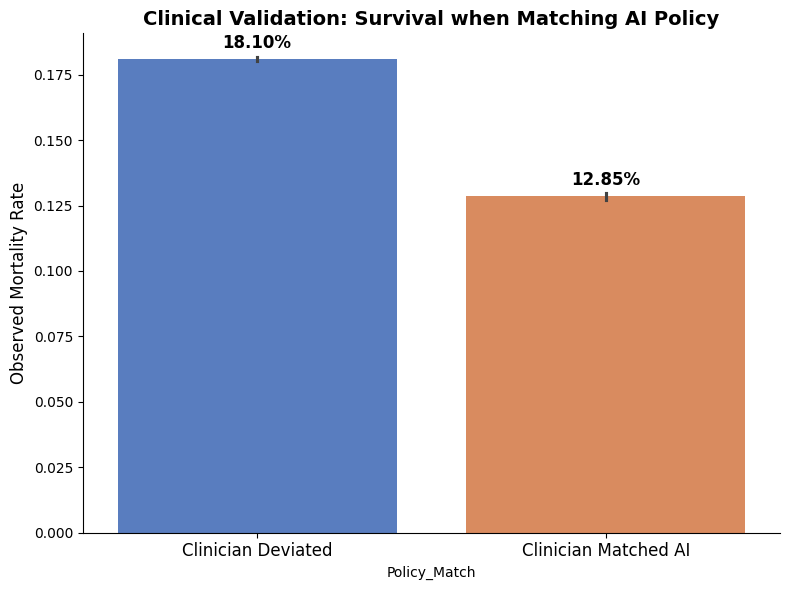

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the results using a Bar Chart
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Policy_Match', y='HOSPITAL_EXPIRE_FLAG', data=dfval, palette='muted')
ax.set_title('Clinical Validation: Survival when Matching AI Policy', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Clinician Deviated', 'Clinician Matched AI'], fontsize=12)
ax.set_ylabel('Observed Mortality Rate', fontsize=12)

# Add percentage labels directly on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Clean up layout and display
sns.despine()
plt.tight_layout()
plt.show()

# **Step 13: Visualizing Treatment Policies (Clinician vs. AI)**

### We  generate side-by-side heatmaps showing the 2D action space (IV Fluids vs. Vasopressors). The Blue heatmap will show what the human doctors actually did (Historical Policy), and the Green heatmap will show what the AI recommended.

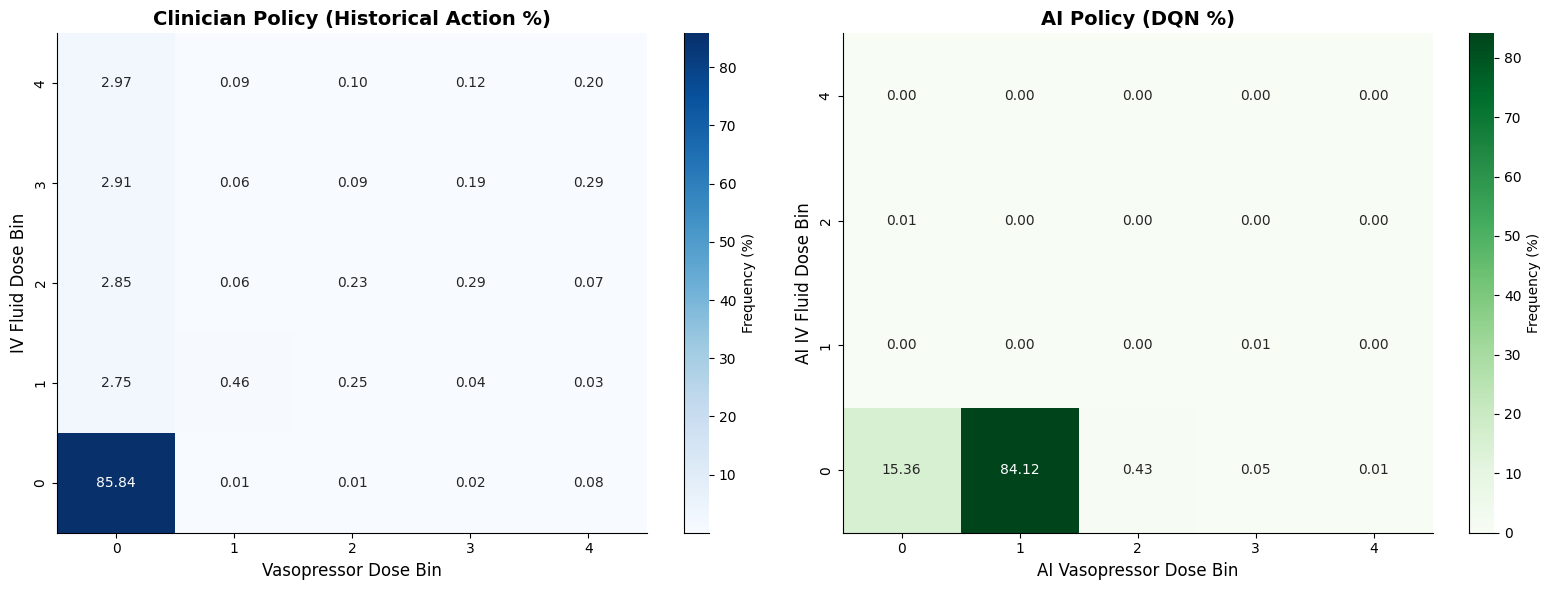

In [42]:
# Calculate the percentage of times each action combination was taken by Doctor
docpivot = pd.crosstab(dfval['IV_Fluid_Bin'], dfval['Vasopressor_Bin'], normalize='all') * 100

# Calculate the percentage of times each action combination was recommended by the AI
aipivot = pd.crosstab(dfval['AI_IV_Fluid_Bin'], dfval['AI_Vasopressor_Bin'], normalize='all') * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1/ Clinician Heatmap
sns.heatmap(docpivot, annot=True, fmt=".2f", cmap="Blues", ax=axes[0],
            cbar_kws={'label': 'Frequency (%)'})
axes[0].set_title('Clinician Policy (Historical Action %)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Vasopressor Dose Bin', fontsize=12)
axes[0].set_ylabel('IV Fluid Dose Bin', fontsize=12)
axes[0].invert_yaxis()

# Subplot 2 /  AI Heatmap
sns.heatmap(aipivot, annot=True, fmt=".2f", cmap="Greens", ax=axes[1],
            cbar_kws={'label': 'Frequency (%)'})
axes[1].set_title('AI Policy (DQN %)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('AI Vasopressor Dose Bin', fontsize=12)
axes[1].set_ylabel('AI IV Fluid Dose Bin', fontsize=12)
axes[1].invert_yaxis()

# Display the plots
sns.despine()
plt.tight_layout()
plt.show()